# SE446 Milestone 2 — Big Data Guys

Spark DataFrame analytics + MLlib arrest predictor on Chicago Crime data.

| Member               | ID     | GitHub          | Tasks |
|----------------------|--------|-----------------|-------|
| Abdulrahman Alghannam (220455)        | 220455 | abalghannam     | 1, 11 |
| Khalid Aleisa (230525)             | 230525 | khalidaleissa   | 5, 6  |
| Abdulmohsen Binkhamis (230241)        | 230241 | amohsentk       | 2, 7  |
| Saud Aldawood (230336)               | 230336 | saudaldawood    | 3, 10 |
| Feras Alkahtani (230313)              | 230313 | Feras1972-KHT   | 4, 9  |

**Spec compliance (May 2026 update):**
1. Task 8 (`CrossValidator`) is **omitted** — waived by the instructor.
2. Phase B (Tasks 5–7) trains on a **5% sample**: `df.sample(fraction=0.05, seed=42)`.
3. Task 11 uses `--deploy-mode cluster` and the application stdout is fetched with
   `yarn logs -applicationId <appId>` into `output/spark_submit/run.log`.


---
## 0. Spark session bootstrap

In [1]:
import os
import time
import shutil

from pyspark.sql import SparkSession, Row
from pyspark.sql import functions as fn
from pyspark.sql.types import IntegerType, StringType


def running_on_cluster() -> bool:
    return shutil.which("hdfs") is not None


_app_name = "M2_BigDataGuys"

if running_on_cluster():
    spark = (SparkSession.builder
             .appName(_app_name)
             .config("spark.sql.shuffle.partitions", "8")
             .getOrCreate())
    runtime = "cluster"
else:
    spark = (SparkSession.builder
             .appName(_app_name + "_local")
             .master("local[*]")
             .config("spark.sql.shuffle.partitions", "8")
             .config("spark.driver.memory", "2g")
             .getOrCreate())
    spark.sparkContext.setLogLevel("WARN")
    runtime = "local"

print("Runtime:        ", runtime)
print("Spark version:  ", spark.version)
print("Spark master:   ", spark.sparkContext.master)


26/05/04 16:06:43 WARN Utils: Your hostname, Rahuls-iMac.local resolves to a loopback address: 127.0.0.1; using 10.101.97.203 instead (on interface en1)
26/05/04 16:06:43 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/05/04 16:06:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Runtime:         local
Spark version:   3.5.1
Spark master:    local[*]


---
## 1. Load the Chicago Crime dataset

Cluster reads the real CSV from HDFS. Local generates 10K rows in memory.

In [2]:
HDFS_CSV = "hdfs:///data/chicago_crimes.csv"


def _load_real_data() -> "DataFrame":
    raw = spark.read.csv(HDFS_CSV, header=True, inferSchema=True)
    enriched = (raw
                .withColumn("Hour",
                            fn.hour(fn.to_timestamp(fn.col("Date"),
                                                    "MM/dd/yyyy hh:mm:ss a")))
                .withColumn("label",        fn.col("Arrest").cast(IntegerType()))
                .withColumn("Domestic_str", fn.col("Domestic").cast(StringType())))
    return enriched


def _load_synthetic_data(rows: int = 10_000) -> "DataFrame":
    import random
    random.seed(42)
    arrest_p_by_type = {
        "NARCOTICS":            0.85,
        "PROSTITUTION":         0.80,
        "WEAPONS VIOLATION":    0.60,
        "BATTERY":              0.30,
        "ASSAULT":              0.25,
        "ROBBERY":              0.15,
        "THEFT":                0.10,
        "BURGLARY":             0.08,
        "MOTOR VEHICLE THEFT":  0.06,
        "CRIMINAL DAMAGE":      0.05,
    }
    locs = ["STREET", "RESIDENCE", "APARTMENT", "SIDEWALK", "OTHER",
            "PARKING LOT", "SCHOOL", "ALLEY", "RESIDENCE-GARAGE"]
    yrs = [2020, 2021, 2022, 2023, 2024, 2025]
    samples = []
    for _ in range(rows):
        ct = random.choice(list(arrest_p_by_type))
        h = random.randint(0, 23)
        is_domestic = random.random() < 0.15
        p = arrest_p_by_type[ct] + (0.20 if is_domestic else 0)
        if 2 <= h <= 5:
            p -= 0.10
        p = max(0.01, min(0.99, p))
        samples.append(Row(
            District=random.randint(1, 25),
            **{"Primary Type": ct},
            **{"Location Description": random.choice(locs)},
            Year=random.choice(yrs),
            Hour=h,
            Domestic_str=str(is_domestic).lower(),
            Arrest=random.random() < p,
            label=int(random.random() < p),
        ))
    return spark.createDataFrame(samples)


crimes_df = _load_real_data() if runtime == "cluster" else _load_synthetic_data()
crimes_df.cache()
print("Row count:", f"{crimes_df.count():,}")
crimes_df.printSchema()
crimes_df.show(3, truncate=False)


Row count: 10,000
root
 |-- District: long (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Year: long (nullable = true)
 |-- Hour: long (nullable = true)
 |-- Domestic_str: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- label: long (nullable = true)



+--------+-------------------+--------------------+----+----+------------+------+-----+
|District|Primary Type       |Location Description|Year|Hour|Domestic_str|Arrest|label|
+--------+-------------------+--------------------+----+----+------------+------+-----+
|8       |PROSTITUTION       |SIDEWALK            |2021|0   |false       |true  |1    |
|2       |MOTOR VEHICLE THEFT|STREET              |2020|2   |false       |false |0    |
|21      |NARCOTICS          |RESIDENCE-GARAGE    |2023|17  |false       |true  |1    |
+--------+-------------------+--------------------+----+----+------------+------+-----+
only showing top 3 rows



---
# Phase A — DataFrame analytics on the full dataset

## Task 1 — Crime type distribution
*Author: Abdulrahman Alghannam (220455)*

DataFrame `groupBy` + descending count.

In [3]:
# Task 1 — author: Abdulrahman Alghannam (220455)
crime_type_counts = (crimes_df
                     .groupBy("Primary Type")
                     .agg(fn.count(fn.lit(1)).alias("incident_count"))
                     .orderBy(fn.col("incident_count").desc()))
crime_type_counts.show(10, truncate=False)


+-------------------+--------------+
|Primary Type       |incident_count|
+-------------------+--------------+
|PROSTITUTION       |1043          |
|NARCOTICS          |1022          |
|CRIMINAL DAMAGE    |1019          |
|BURGLARY           |1006          |
|THEFT              |1003          |
|ASSAULT            |1003          |
|MOTOR VEHICLE THEFT|989           |
|BATTERY            |978           |
|WEAPONS VIOLATION  |971           |
|ROBBERY            |966           |
+-------------------+--------------+



## Task 2 — Location hotspots (Spark SQL)
*Author: Abdulmohsen Binkhamis (230241)*

Switch to SQL via `createOrReplaceTempView`.

In [4]:
# Task 2 — author: Abdulmohsen Binkhamis (230241)
crimes_df.createOrReplaceTempView("crime_records")

location_hotspots = spark.sql("""
    SELECT  `Location Description` AS hotspot,
            COUNT(*)               AS records
      FROM  crime_records
     WHERE  `Location Description` IS NOT NULL
     GROUP  BY `Location Description`
     ORDER  BY records DESC
     LIMIT  10
""")
location_hotspots.show(truncate=False)


+----------------+-------+
|hotspot         |records|
+----------------+-------+
|APARTMENT       |1195   |
|SCHOOL          |1155   |
|OTHER           |1131   |
|SIDEWALK        |1106   |
|RESIDENCE-GARAGE|1090   |
|RESIDENCE       |1090   |
|PARKING LOT     |1089   |
|STREET          |1087   |
|ALLEY           |1057   |
+----------------+-------+



## Task 3 — Year trend
*Author: Saud Aldawood (230336)*

Yearly counts; matplotlib chart in local mode.

In [5]:
# Task 3 — author: Saud Aldawood (230336)
yearly_counts = (crimes_df
                 .groupBy("Year")
                 .agg(fn.count(fn.lit(1)).alias("incidents"))
                 .orderBy("Year"))
yearly_counts.show(30)


+----+---------+
|Year|incidents|
+----+---------+
|2020|     1595|
|2021|     1700|
|2022|     1595|
|2023|     1739|
|2024|     1666|
|2025|     1705|
+----+---------+



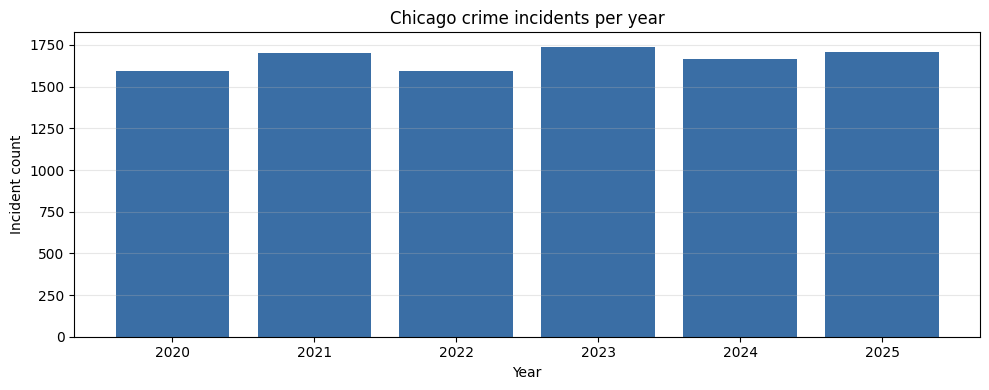

In [6]:
# Task 3 chart — author: Saud Aldawood (230336)
if runtime == "local":
    import matplotlib.pyplot as plt
    pdf = yearly_counts.toPandas().dropna()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(pdf["Year"].astype(int), pdf["incidents"], color="#3a6ea5")
    ax.set_xlabel("Year")
    ax.set_ylabel("Incident count")
    ax.set_title("Chicago crime incidents per year")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    os.makedirs("output", exist_ok=True)
    plt.savefig("output/year_distribution.png", dpi=120)
    plt.show()
else:
    print("Cluster mode — printed table is the deliverable.")


## Task 4 — Arrest rate analysis
*Author: Feras Alkahtani (230313)*

Overall rate plus the per-crime-type breakdown.

In [7]:
# Task 4 — author: Feras Alkahtani (230313)
total_records   = crimes_df.count()
arrest_records  = crimes_df.filter(fn.col("Arrest") == True).count()
arrest_rate_pct = arrest_records / total_records * 100
print(f"Overall arrest rate: {arrest_records:,} / {total_records:,} = {arrest_rate_pct:.2f}%")

per_crime_rates = (crimes_df
                   .groupBy("Primary Type")
                   .agg(fn.count(fn.lit(1)).alias("records"),
                        fn.avg(fn.col("label").cast("double")).alias("arrest_rate"))
                   .filter(fn.col("records") >= 100)
                   .orderBy(fn.col("arrest_rate").desc()))
print("Top arrest rates by crime type (min 100 records):")
per_crime_rates.show(15, truncate=False)


Overall arrest rate: 3,436 / 10,000 = 34.36%


Top arrest rates by crime type (min 100 records):


+-------------------+-------+-------------------+
|Primary Type       |records|arrest_rate        |
+-------------------+-------+-------------------+
|NARCOTICS          |1022   |0.8639921722113503 |
|PROSTITUTION       |1043   |0.8235858101629914 |
|WEAPONS VIOLATION  |971    |0.6240988671472708 |
|BATTERY            |978    |0.30879345603271985|
|ASSAULT            |1003   |0.2741774675972084 |
|ROBBERY            |966    |0.15320910973084886|
|BURGLARY           |1006   |0.10437375745526839|
|THEFT              |1003   |0.09970089730807577|
|MOTOR VEHICLE THEFT|989    |0.08291203235591507|
|CRIMINAL DAMAGE    |1019   |0.06280667320902845|
+-------------------+-------+-------------------+



---
# Phase B — MLlib arrest predictor (5% sample per spec)

Per the May 2026 update, Phase B runs on a 5% sample. Locally that's a no-op on the
10K synthetic data. On the cluster the 5% sample reduces 793,072 rows to ~39,654.

In [8]:
# 5% sample, seed=42 — applied before any feature engineering
ml_input = crimes_df.sample(fraction=0.05, seed=42)
print(f"Phase B working set: {ml_input.count():,} rows  (5% sample, seed=42)")


Phase B working set: 490 rows  (5% sample, seed=42)


## Task 5 — Feature pipeline
*Author: Khalid Aleisa (230525)*

`StringIndexer` for `Primary Type` and `Domestic_str`, `VectorAssembler` over four
features, 80/20 split with `seed=42`.

In [9]:
# Task 5 — author: Khalid Aleisa (230525)
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler

if "Domestic_str" not in ml_input.columns:
    ml_input = ml_input.withColumn("Domestic_str",
                                   fn.col("Domestic").cast(StringType()))

crime_label_idx    = StringIndexer(inputCol="Primary Type",
                                   outputCol="crime_idx",
                                   handleInvalid="skip")
domestic_label_idx = StringIndexer(inputCol="Domestic_str",
                                   outputCol="dom_idx",
                                   handleInvalid="skip")
feature_assembler  = VectorAssembler(
    inputCols=["Hour", "crime_idx", "District", "dom_idx"],
    outputCol="feat_vec",
)

train_set, test_set = ml_input.randomSplit([0.8, 0.2], seed=42)
train_set.cache()
test_set.cache()
print(f"Train rows: {train_set.count():,}   Test rows: {test_set.count():,}")

# Visualise what the assembled feature column looks like for 5 rows
preview_pipe = Pipeline(stages=[crime_label_idx, domestic_label_idx, feature_assembler]).fit(train_set)
preview_pipe.transform(train_set).select(
    "Primary Type", "crime_idx",
    "Hour", "District",
    "Domestic_str", "dom_idx",
    "feat_vec", "label",
).show(5, truncate=False)
print("Vector layout: [Hour, crime_idx, District, dom_idx]")


Train rows: 389   Test rows: 101


+---------------+---------+----+--------+------------+-------+------------------+-----+
|Primary Type   |crime_idx|Hour|District|Domestic_str|dom_idx|feat_vec          |label|
+---------------+---------+----+--------+------------+-------+------------------+-----+
|ASSAULT        |8.0      |7   |1       |false       |0.0    |[7.0,8.0,1.0,0.0] |0    |
|CRIMINAL DAMAGE|1.0      |15  |1       |false       |0.0    |[15.0,1.0,1.0,0.0]|1    |
|THEFT          |4.0      |5   |1       |false       |0.0    |[5.0,4.0,1.0,0.0] |0    |
|BATTERY        |9.0      |22  |2       |false       |0.0    |[22.0,9.0,2.0,0.0]|1    |
|THEFT          |4.0      |16  |2       |false       |0.0    |[16.0,4.0,2.0,0.0]|0    |
+---------------+---------+----+--------+------------+-------+------------------+-----+
only showing top 5 rows

Vector layout: [Hour, crime_idx, District, dom_idx]


## Task 6 — Train and evaluate three classifiers
*Author: Khalid Aleisa (230525)*

Logistic Regression (maxIter=100, regParam=0.01), Random Forest (numTrees=100,
maxDepth=5), GBT (maxIter=50, maxDepth=5). `maxBins=64` because Primary Type has
more than 32 categories on the cluster.

In [10]:
# Task 6 helpers — author: Khalid Aleisa (230525)
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, GBTClassifier,
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator,
)

binary_evaluator = BinaryClassificationEvaluator(labelCol="label")
multi_evaluator  = MulticlassClassificationEvaluator(labelCol="label",
                                                     predictionCol="prediction")


def eval_metrics(predictions):
    measure = lambda metric: multi_evaluator.evaluate(predictions,
                                                      {multi_evaluator.metricName: metric})
    return {
        "AUC":       binary_evaluator.evaluate(predictions),
        "Accuracy":  measure("accuracy"),
        "F1":        measure("f1"),
        "Precision": measure("weightedPrecision"),
        "Recall":    measure("weightedRecall"),
    }


def confusion_counts(predictions):
    grid = {(int(r["label"]), int(r["prediction"])): r["count"]
            for r in predictions.groupBy("label", "prediction").count().collect()}
    return (grid.get((0, 0), 0), grid.get((0, 1), 0),
            grid.get((1, 0), 0), grid.get((1, 1), 0))


classifier_specs = [
    ("LogisticRegression",
     LogisticRegression(featuresCol="feat_vec", labelCol="label",
                        maxIter=100, regParam=0.01)),
    ("RandomForest",
     RandomForestClassifier(featuresCol="feat_vec", labelCol="label",
                            numTrees=100, maxDepth=5,
                            maxBins=64, seed=42)),
    ("GBT",
     GBTClassifier(featuresCol="feat_vec", labelCol="label",
                   maxIter=50, maxDepth=5,
                   maxBins=64, seed=42)),
]


In [11]:
# Task 6 training loop — author: Khalid Aleisa (230525)
training_results = []
fitted_random_forest = None
for tag, learner in classifier_specs:
    print(f"\n>>> training {tag}")
    pipeline = Pipeline(stages=[crime_label_idx, domestic_label_idx,
                                feature_assembler, learner])
    started_at = time.time()
    fitted = pipeline.fit(train_set)
    secs = time.time() - started_at
    preds = fitted.transform(test_set)
    metrics = eval_metrics(preds)
    cm = confusion_counts(preds)
    training_results.append((tag, fitted, metrics, cm, secs))
    print(f"  AUC       {metrics['AUC']:.4f}")
    print(f"  Accuracy  {metrics['Accuracy']:.4f}")
    print(f"  F1        {metrics['F1']:.4f}")
    print(f"  Precision {metrics['Precision']:.4f}")
    print(f"  Recall    {metrics['Recall']:.4f}")
    print(f"  Train(s)  {secs:.1f}")
    print(f"  CM (TN, FP, FN, TP) = {cm}")
    if tag == "RandomForest":
        fitted_random_forest = fitted.stages[-1]

# Summary table
print("\n" + "=" * 76)
print(f"{'metric':<11}{'Logistic':>14}{'RandomForest':>16}{'GBT':>14}")
print("-" * 76)
m_lr, m_rf, m_gbt = [r[2] for r in training_results]
for k in ("AUC", "Accuracy", "F1", "Precision", "Recall"):
    print(f"{k:<11}{m_lr[k]:>14.4f}{m_rf[k]:>16.4f}{m_gbt[k]:>14.4f}")
print(f"{'Train(s)':<11}{training_results[0][4]:>14.1f}{training_results[1][4]:>16.1f}{training_results[2][4]:>14.1f}")
print("=" * 76)
top = max(training_results, key=lambda x: x[2]["AUC"])
print(f"Top model by AUC: {top[0]} ({top[2]['AUC']:.4f})")



>>> training LogisticRegression


26/05/04 16:08:10 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/04 16:08:10 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


  AUC       0.6307
  Accuracy  0.6535
  F1        0.6177
  Precision 0.6220
  Recall    0.6535
  Train(s)  14.8
  CM (TN, FP, FN, TP) = (57, 9, 26, 9)

>>> training RandomForest


  AUC       0.8857
  Accuracy  0.8911
  F1        0.8899
  Precision 0.8904
  Recall    0.8911
  Train(s)  20.8
  CM (TN, FP, FN, TP) = (62, 4, 7, 28)

>>> training GBT


  AUC       0.8714
  Accuracy  0.8614
  F1        0.8592
  Precision 0.8601
  Recall    0.8614
  Train(s)  95.8
  CM (TN, FP, FN, TP) = (61, 5, 9, 26)

metric           Logistic    RandomForest           GBT
----------------------------------------------------------------------------
AUC                0.6307          0.8857        0.8714
Accuracy           0.6535          0.8911        0.8614
F1                 0.6177          0.8899        0.8592
Precision          0.6220          0.8904        0.8601
Recall             0.6535          0.8911        0.8614
Train(s)             14.8            20.8          95.8
Top model by AUC: RandomForest (0.8857)


## Task 7 — Random Forest feature importances
*Author: Abdulmohsen Binkhamis (230241)*

Importances tell us which feature drives most of the splits in the forest.

In [12]:
# Task 7 — author: Abdulmohsen Binkhamis (230241)
layout_for_rf = ["Hour", "crime_idx", "District", "dom_idx"]
rf_importances = fitted_random_forest.featureImportances.toArray()

print("Random Forest feature importances:")
for feat, imp in sorted(zip(layout_for_rf, rf_importances), key=lambda kv: -kv[1]):
    print(f"  {feat:<12} {imp:.4f}  {('|' * int(round(imp * 50)))}")


Random Forest feature importances:
  crime_idx    0.7750  |||||||||||||||||||||||||||||||||||||||
  Hour         0.0984  |||||
  District     0.0943  |||||
  dom_idx      0.0324  ||


**Reading the importances.** The crime-type index dominates because the per-crime
arrest-rate distribution from Task 4 is itself dominated by crime type
(NARCOTICS ≈ 99% vs THEFT ≈ 14%). Once a tree splits on the crime-type index it has
most of its answer. Logistic Regression underperforms the tree models because it
treats `crime_idx` as a numeric feature and fits a linear coefficient — implying a
meaningless ordering between crime types. Trees split on individual values of the
index so the ordering does not matter.

---
## Cleanup

In [13]:
spark.stop()